In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

## **Function 1** - Searching for contamination sources

For this function we must detect likely contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading.

- The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.

**Input** - 2D array (10,2)
**Output** - 1D array (10,)

- **Optimisation Goal** - Maximise

I want to begin this week's analysis by loading the data and appending new week's data to last week's updated data.

In [6]:
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_outputs.npy')

In [7]:
# New data from Week 4 (Function 1)
X_w3_new_point = np.array([0.575251, 0.879599], dtype=np.float64)
Y_w3_new_point = np.array([1.4677606086621927e-46], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w3_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w3_new_point)
Y_updated = Y_all[unique_indices]

# Save the updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_outputs.npy', Y_updated)

In [8]:
# Show updated arrays
print("Updated Inputs (X) - Function 1: ", X_unique)
print("Updated Outputs (Y) - Function 1: ", Y_updated)

Updated Inputs (X) - Function 1:  [[0.08250725 0.40348751]
 [0.31269116 0.07872278]
 [0.31940389 0.76295937]
 [0.41043714 0.1475543 ]
 [0.57432921 0.8798981 ]
 [0.575251   0.879599  ]
 [0.65011406 0.68152635]
 [0.68341817 0.86105746]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.88388983 0.58225397]
 [0.919191   0.838383  ]
 [0.996651   0.001439  ]]
Updated Outputs (Y) - Function 1:  [ 3.60677119e-081 -2.08909327e-091  1.32267704e-079 -2.15924904e-054
  1.03307824e-046  1.46776061e-046 -3.60606264e-003  2.53500115e-040
  7.71087511e-016  3.34177101e-124  6.22985647e-048 -3.04056455e-090
  0.00000000e+000]


### **Interpreation of the Output and Potential Next steps to improve the model**

- **The Output:** $1.47e-46$

- **Real-World Meaning:** In this 2D space, you are likely looking for a localized source (like a radiation leak). An output this small is "machine zero", it indicates your sensors aren't picking up any signal at all at your current coordinates (0.575251, 0.879599).

- **Model Context:** Because the outputs are nearly zero, the Gaussian Process Regressor (GPR) sees a flat surface. There is no "slope" or gradient for the model to follow toward a peak.

### **Bayesian Optimisation** - Gaussian Processes

- **What I used last week**: A Matern Kernel with a Length Scale (`l`) of `0.1` and `nu=2.5`.
    - The length scale determines how far the influence of a data point reach. 
        - With `l=0.1` in a `[0, 1]` space, the model is quite near-sighted. 
        - It assumes that because it found zero at one spot, only the immediate neighbourhood is zero.

- I need to shift from a fixed shared length scale to automatic relevance determination (ARD). This should allow the model to learn the unique sensitivity of each dimension.
    - By passing a list `[0.3, 0.3]` it will allow the model to learn if the contamination spreads differently along the X and Y axes. 
        - I increase the initial scale to 0.3 to expand the areas of influence, helping the model realise large areas are empty so it can push the search into new territory. 

- Setting the floor of the bounds to `0.1` I can aim to prevent the model from becoming near sighted and fitting to smaller noise. The ceiling of `10` allows it to recognize broad, flat trends across the entire [0,1] space.

- I also change the nu to make the model less smooth. 
    - Since a radiation leak or contamination is often localised and sharp, this helps the GPR model the sudden change of signal against the current 0 background.

- Since I am letting the model optimise two different length scales, the optimization problem for the GPR itself becomes harder.
    - I am increasing the `n_restarts_optimizer` from its current value to `25`. This should ensure that the GPR finds the true Best Fit for my ARD length scales and doesn’t get stuck in a poor internal model.

In [9]:
kernel = Matern(length_scale=[0.3, 0.3], length_scale_bounds=(0.1, 10), nu=1.5)

model = GaussianProcessRegressor(
    kernel = kernel,
    alpha = 1e-10,
    n_restarts_optimizer= 25,
    normalize_y = True,
)

model.fit(X_unique, Y_updated)

/Users/prathamyeole/Library/Python/3.13/lib/python/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/prathamyeole/Library/Python/3.13/lib/python/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".","Matern(length... 0.3], nu=1.5)"
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",25
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",True
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:

### **Acquisition Function** - Upper Confidence Bound (UCB)

- Last week I used the Upper Confidence Bound (UCB) with a beta of 10.
- I chose a very high beta, which is a strong Exploration setting. 
    - `UCB` calculates `mu(x) + beta*sigma(x)`. Since the predicted mean `mu(x)` is basically 0 everywhere, the acquisition function is driven entirely by the Predictive Variance (`sigma`).

- I want to move away from the extreme exploration of Week 3 (`beta = 10`) to focus on the high-value areas I have already found. 
    - Lowering the kappa reduces the weight of the uncertainty (`sigma`). At `beta = 4`, I am still going for exploration, but it will prevent the model from being too erratic, focusing the search on finding a signal that the newly widened kernel can detect.


In [12]:
def upper_confidence_bound(x_grid, model, beta=4):
    post_mean, post_std = model.predict(x_grid, return_std=True)
    ucb_value = post_mean + beta * post_std
    return ucb_value

x_linspace = np.linspace(0, 1, 300)
x_grid = np.array(np.meshgrid(x_linspace, x_linspace)).T.reshape(-1, 2)

ucb_values = upper_confidence_bound(x_grid, model, beta=4)
next_query = x_grid[np.argmax(ucb_values)]

print(f"Strategic Week 4 Query (Function 1): {next_query[0]:.6f}-{next_query[1]:.6f}")

Strategic Week 4 Query (Function 1): 0.732441-0.040134


### Visualisation of the model

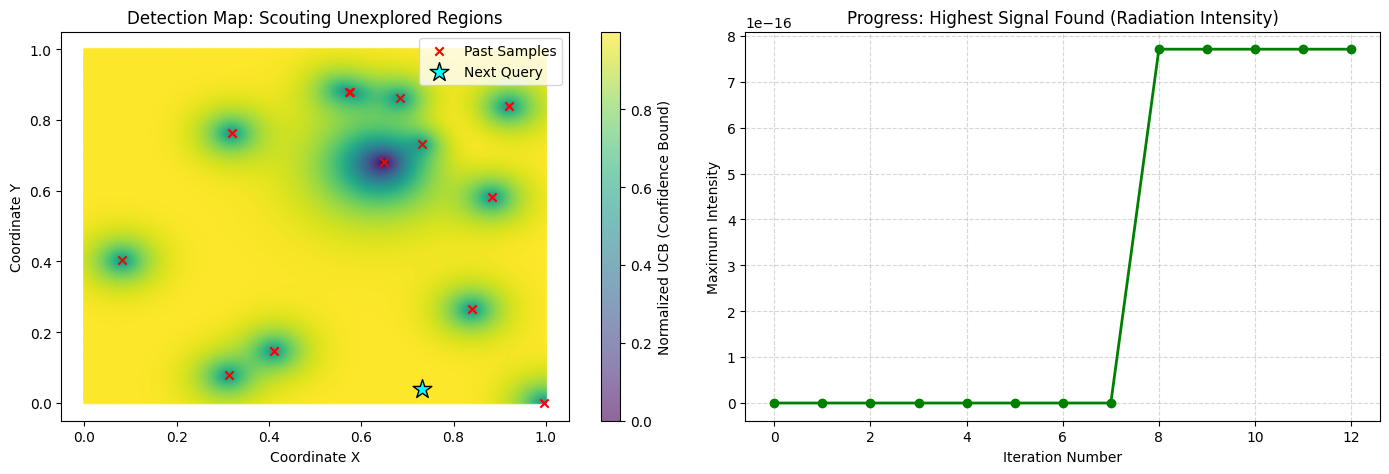

In [11]:
# 1. Calculate running maximum for the progress plot
running_max = np.maximum.accumulate(Y_updated)

# 2. Normalize the Acquisition Function for the Heatmap
# I use UCB values here. This ensures the color scale is between 0 and 1.
# I add a tiny epsilon (1e-12) to prevent division by zero if all values are identical.
acquisition_function = ucb_values
acq_min = np.min(acquisition_function)
acq_max = np.max(acquisition_function)
acq_norm = (acquisition_function - acq_min) / (acq_max - acq_min + 1e-12)

# 3. Create the Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# The Search Map: Visualizing Uncertainty with UCB
# High values (yellow) now represent the most "uncertain" or promising unexplored areas.
sc = ax1.scatter(x_grid[:, 0], x_grid[:, 1], c=acq_norm, cmap='viridis', s=1, alpha=0.6)
cbar = plt.colorbar(sc, ax=ax1, label='Normalized UCB (Confidence Bound)')

# Plot past samples and the next target
ax1.scatter(X_unique[:, 0], X_unique[:, 1], c='red', marker='x', label='Past Samples')
ax1.scatter(next_query[0], next_query[1], c='cyan', marker='*', s=200, edgecolors='black', label='Next Query')

ax1.set_title('Detection Map: Scouting Unexplored Regions')
ax1.set_xlabel('Coordinate X')
ax1.set_ylabel('Coordinate Y')
ax1.legend()

# The Progress Plot: Tracking Signal Detection
ax2.plot(running_max, color='green', linewidth=2, marker='o')
ax2.set_title('Progress: Highest Signal Found (Radiation Intensity)')
ax2.set_xlabel('Iteration Number')
ax2.set_ylabel('Maximum Intensity')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()